# Sensitivity analysis with XGBoost imputation

In [1]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()

model_path = os.getenv('MODEL')

data_path = os.getenv('TRAINING_DATA')
train = pd.read_csv(data_path)
train = train.dropna()
train = train.drop(columns = 'Studio')
train.shape

(3599, 19)

In [2]:
import bagging
from xgboost import Booster
labelcols = {
    'lower': 'esrd_lower',
    'upper': 'esrd_upper'
}
best_params = {'objective': 'survival:aft',
               'eval_metric': 'aft-nloglik',
               'aft_loss_distribution': 'extreme',
               'aft_loss_distribution_scale': 0.1,
               'tree_method': 'hist',
               'learning_rate': 0.01,
               'max_depth': [8,10],
               'booster': 'gbtree',
               'subsample': 1.0,
               'min_child_weight': 1.0,
               'colsample_bynode': 1.0,
               'n_models': 50,
               'subset_fraction': 1.0}
model = bagging.BaggingXGBRegressor(params = best_params, 
                                    labelcols=labelcols, 
                                    verbose = True)
model._BaggingXGBRegressor__models = []
for m_path in os.listdir(model_path):
    m = Booster()
    m.load_model(f'{model_path}/{m_path}')
    model._BaggingXGBRegressor__models.append(m)

/Users/tamasszili-torok/Research/machine_learning/ESKD-predict/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Import the results of the feature selection
import json
with open('raw_results/feature_selection_results.json') as f:
    var_dict = json.load(f)
df_feat_import = pd.DataFrame({'feat': var_dict['feat'], 'c_index': var_dict['c_index']})
df_feat_import['c_index'] = round(df_feat_import['c_index'], 2)
selected_feat = list(df_feat_import['feat'])[:np.argmax(df_feat_import['c_index']) + 3]
selected_feat

['Epi1', 'Prot1', 'BMI1', 'Eta1', 'P1', 'Ca1', 'Hb1', 'Colesterolo1']

In [4]:
# First median/mode impoutation
nat_val_data_path = os.getenv('NATIONAL_VAL')
test_raw = pd.read_csv(nat_val_data_path)
test = test_raw.loc[test_raw['Studio'] == 7]
test = test[list(selected_feat + [labelcols['lower'], labelcols['upper']])]
print(test.shape)
print(test.columns)
test.rename(columns={'Epi1': 'EGFR', 
                      'Prot1': 'URIN_PROT', 
                      'BMI1': 'BMI', 
                      'Eta1': 'AGE', 
                      'P1': 'PHOSPHORUS', 
                      'Ca1': 'CALCIUM', 
                      'Hb1': 'HB', 
                      'Colesterolo1': 'CHOLESTEROL'}, inplace=True)
print(test.columns)

(358, 10)
Index(['Epi1', 'Prot1', 'BMI1', 'Eta1', 'P1', 'Ca1', 'Hb1', 'Colesterolo1',
       'esrd_lower', 'esrd_upper'],
      dtype='object')
Index(['EGFR', 'URIN_PROT', 'BMI', 'AGE', 'PHOSPHORUS', 'CALCIUM', 'HB',
       'CHOLESTEROL', 'esrd_lower', 'esrd_upper'],
      dtype='object')


In [5]:
predicted_test = model.predict(test, output_margin = False)

# Aggregate the predictions
predicted_aggr = np.round(np.mean(predicted_test, axis = 0), 1)
predicted_ci = np.round(np.std(predicted_test, axis = 0) * 1.96, 1)

In [6]:
import lifelines
print('National validation:\n')

event_times = test['esrd_lower'].to_numpy()
event_observed = (test['esrd_upper'] == test['esrd_lower']).astype(int).to_numpy()
print('Model performance (c-index): ' + str(round(lifelines.utils.concordance_index(event_times, predicted_aggr, event_observed),3)) + '\n')

print('Median of time to ESRD development: ' + str(round(np.median(event_times[np.where(event_observed == 1)]), 1)) + 
      '. Median of predicted time to ESRD development: ' + str(round(np.median(predicted_aggr[np.where(event_observed == 1)]), 1)))
print('Median time for censored cases: ' + str(round(np.median(event_times[np.where(event_observed == 0)]), 1)) + 
          '. Median time predicted for censored cases: ' + str(round(np.median(predicted_aggr[np.where(event_observed == 0)]), 1)))
print('Median overall time: ' + str(round(np.median(event_times), 1)) + 
          '. Median overall predicted time: ' + str(round(np.median(predicted_aggr), 1)))

National validation:

Model performance (c-index): 0.848

Median of time to ESRD development: 30.8. Median of predicted time to ESRD development: 33.4
Median time for censored cases: 62.7. Median time predicted for censored cases: 106.4
Median overall time: 51.4. Median overall predicted time: 76.8


In [7]:
intl_val_data_path = os.getenv('INTL_VAL')
intl_val_incl_sex_data_path = os.getenv('INTL_VAL_EXTRA_DATA')
test_intl_raw = pd.read_csv(intl_val_data_path)
test_intl_raw = test_intl_raw.merge(pd.read_csv(intl_val_incl_sex_data_path), on='ID_UMCG')
test_intl_raw = test_intl_raw.drop(columns = 'ID_UMCG')
test_intl_raw.shape

(368, 18)

In [8]:
test_intl_raw.rename(columns={'Epi1': 'EGFR',
                              'Proteinurieurine': 'URIN_PROT',
                              'bmi': 'BMI',
                              'age': 'AGE',
                              'Fosfaat': 'PHOSPHORUS',
                              'Calciumbloed': 'CALCIUM',
                              'Hbmmolperliter': 'HB',
                              'totaalcholesterol': 'CHOLESTEROL'}, inplace=True)
# Convert features into the correct units
# https://www.ukkidney.org/sites/renal.org/files/Appendix-I_0.pdf
test_intl_raw['PHOSPHORUS'] = test_intl_raw['PHOSPHORUS'] * 3.1
test_intl_raw['CALCIUM'] = test_intl_raw['CALCIUM'] * 4
test_intl_raw['CHOLESTEROL'] = test_intl_raw['CHOLESTEROL'] * 38.6
# https://www.unitsconverters.com/en/Mmol/L-To-G/Dl/Utu-6013-6012
test_intl_raw['HB'] = test_intl_raw['HB'] * 1.6113
test_intl = test_intl_raw[test.columns]
#test_intl = test_intl[test_intl['EGFR'] <= 60]
test_intl.columns

Index(['EGFR', 'URIN_PROT', 'BMI', 'AGE', 'PHOSPHORUS', 'CALCIUM', 'HB',
       'CHOLESTEROL', 'esrd_lower', 'esrd_upper'],
      dtype='object')

In [9]:
test_intl = test_intl[test.columns]
num_vars = ['EGFR', 'URIN_PROT', 'BMI', 'AGE', 'PHOSPHORUS', 'CALCIUM', 'HB', 'CHOLESTEROL']
test_intl.shape

(368, 10)

In [10]:
predicted_test_intl = model.predict(test_intl, output_margin = False)

# Aggregate the predictions
predicted_aggr_intl = np.round(np.mean(predicted_test_intl, axis = 0), 1)
predicted_ci_intl = np.round(np.std(predicted_test_intl, axis = 0) * 1.96, 1) 

In [11]:
event_times_intl = test_intl['esrd_lower'].to_numpy()
event_observed_intl = (test_intl['esrd_upper'] == test_intl['esrd_lower']).astype(int).to_numpy()

print('International validation:\n')

print('Model performance (c-index): ' + str(round(lifelines.utils.concordance_index(event_times_intl, predicted_aggr_intl, event_observed_intl),3)) + '\n')

print('Median of time to ESRD development: ' + str(round(np.median(event_times_intl[np.where(event_observed_intl == 1)]), 1)) + 
      '. Median of predicted time to ESRD development: ' + str(round(np.median(predicted_aggr_intl[np.where(event_observed_intl == 1)]), 1)))
print('Median time for censored cases: ' + str(round(np.median(event_times_intl[np.where(event_observed_intl == 0)]), 1)) + 
          '. Median time predicted for censored cases: ' + str(round(np.median(predicted_aggr_intl[np.where(event_observed_intl == 0)]), 1)))
print('Median overall time: ' + str(round(np.median(event_times_intl), 1)) + 
          '. Median overall predicted time: ' + str(round(np.median(predicted_aggr_intl), 1)))

International validation:

Model performance (c-index): 0.871

Median of time to ESRD development: 52.6. Median of predicted time to ESRD development: 46.0
Median time for censored cases: 118.6. Median time predicted for censored cases: 111.8
Median overall time: 82.9. Median overall predicted time: 91.2


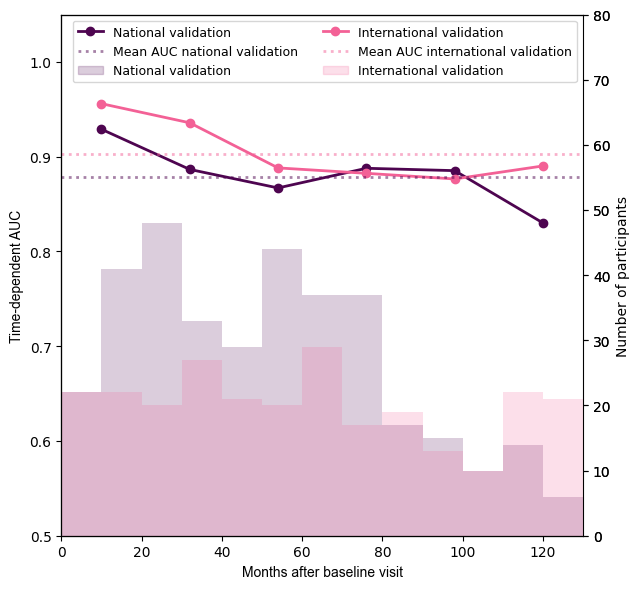

In [12]:
from sksurv.metrics import (
    as_concordance_index_ipcw_scorer,
    as_cumulative_dynamic_auc_scorer,
    as_integrated_brier_score_scorer,
)
import seaborn as sns
from sksurv import metrics as sksurvmetrics
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

event_observed_train = (train['esrd_upper'] == train['esrd_lower']).astype(bool).to_numpy()
event_observed_test = (test['esrd_upper'] == test['esrd_lower']).astype(bool).to_numpy()

# The survival times need to be negative in order to transform them into a risk score.
auc_nat, mean_auc_nat = sksurvmetrics.cumulative_dynamic_auc(np.array(list(zip(event_observed_train, train['esrd_lower'])), dtype=[('event', '?'), ('time', '<f8')]), 
                                                     np.array(list(zip(event_observed_test, test['esrd_lower'])), dtype=[('event', '?'), ('time', '<f8')]), 
                                                     -predicted_aggr, 
                                                     np.linspace(10, 120, 6)
                                                    )

# The survival times need to be negative in order to transform them into a risk score.
auc_intl, mean_auc_intl = sksurvmetrics.cumulative_dynamic_auc(np.array(list(zip(event_observed_train, train['esrd_lower'])), dtype=[('event', '?'), ('time', '<f8')]), 
                                                     np.array(list(zip(event_observed_intl, test_intl['esrd_lower'])), dtype=[('event', '?'), ('time', '<f8')]), 
                                                     -predicted_aggr_intl, 
                                                     np.linspace(10, 120, 6)
                                                    )

fig, ax = plt.subplots(figsize = (6.5, 6.0))

ax_density_nat = ax.twinx()
ax_density_intl = ax.twinx()

sns.histplot(event_times, fill=True, color='xkcd:plum purple', linewidth = 0.0, alpha=0.20, bins = np.linspace(0, 180, 19), ax=ax_density_nat, zorder=1)
sns.histplot(event_times_intl, fill=True, color='xkcd:medium pink', linewidth = 0.0, alpha=0.20, bins = np.linspace(0, 180, 19), ax=ax_density_intl, zorder=1)

ax_density_nat.set_yticks(np.linspace(0,80, 9))
ax_density_nat.spines['right'].set_visible(False)
ax_density_nat.set_ylabel('')

ax_density_intl.set_yticks(np.linspace(0,80, 9))
ax_density_intl.spines['right'].set_visible(False)
ax_density_intl.set_ylabel('Number of participants')

line1, = ax.plot(np.linspace(10, 120, 6), auc_nat, label = 'National validation', marker="o", color = 'xkcd:plum purple', linewidth = 2.0)
line2, = ax.plot(np.linspace(10, 120, 6), auc_intl, label = 'International validation', marker="o", color = 'xkcd:medium pink', linewidth = 2.0)
ax.set_ylim(0.5,1.05)
ax.set_xlim(0.0,130.0)
ax.set_xlabel("Months after baseline visit", fontname = 'arial')
ax.set_ylabel("Time-dependent AUC", fontname = 'arial')
line3, = ax.plot([0, 130], [mean_auc_nat, mean_auc_nat], label = 'Mean AUC national validation', linestyle = "dotted", color = 'xkcd:plum purple', alpha = 0.5, linewidth = 2.0)
line4, = ax.plot([0, 130], [mean_auc_intl, mean_auc_intl], label = 'Mean AUC international validation', linestyle = "dotted", color = 'xkcd:medium pink', alpha = 0.5, linewidth = 2.0)

nat_patch = Patch(color='xkcd:plum purple', alpha=0.20, label='National validation')
intl_patch = Patch(color='xkcd:medium pink', alpha=0.20, label='International validation')
ax.legend(ncols = 2,handles=[line1, line3, nat_patch, line2, line4,  intl_patch], loc='upper right', fontsize = 9)

plt.tight_layout()
plt.savefig("figures/auc_sensitivity_analysis_xgboost_imp.pdf")
plt.show()

In [13]:
def count_has_less_than_min_cases(counts, min_cases):
    return any(counts < min_cases)

def merge_intervals(interval1, interval2):
    return pd.Interval(left=min(interval1.left, interval2.left), right=max(interval1.right, interval2.right), closed='both')

def merge_small_bins(df, column, min_cases):
    
    counts = df[column].value_counts(sort=True)
    
    counts = counts[counts != 0]
    counts = counts.sort_index(ascending = False)
    indices = counts.index
    index_right = indices[0].right
    new_bins = []

    while count_has_less_than_min_cases(counts, min_cases):
        i = 0
        for index, count in counts.items():
            if count < min_cases:
                if i == len(counts):
                    merge_with_interval = counts.index[i-1]
                else:
                    merge_with_interval = counts.index[i+1]
                    
                new_interval = merge_intervals(interval1 = merge_with_interval, interval2 = index)
                new_count = count + counts[merge_with_interval]
                add_series = pd.Series([new_count], index = [new_interval])
                counts = counts.drop([merge_with_interval, index])
                counts = pd.concat([add_series, counts])
                break
            else:
                i += 1
                
    print('New splits:\n' + str(counts.sort_index(ascending = True)))

    left_bounds = [interval.left for interval in counts.index]
    right_bounds = [interval.right for interval in counts.index]
    all_bounds = sorted(set(left_bounds + right_bounds))
    df[column] = pd.cut(df['real'], bins = all_bounds)
    
    return df, all_bounds

New splits:
(0.0, 20.0]      44
(20.0, 40.0]     37
(40.0, 60.0]     31
(60.0, 80.0]     14
[80.0, 120.0]     8
dtype: int64
New splits:
(0.0, 20.0]       32
(20.0, 40.0]      21
(40.0, 60.0]      22
(60.0, 80.0]      21
(80.0, 100.0]     14
(100.0, 120.0]    11
(120.0, 140.0]     5
[140.0, 180.0]     9
dtype: int64


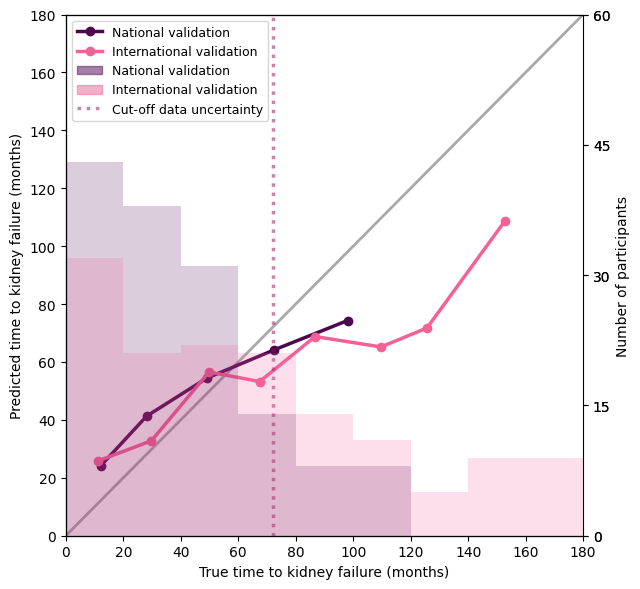

In [14]:
df_plot = pd.DataFrame({'real': event_times[np.where(event_observed == 1)], 'predicted': predicted_aggr[np.where(event_observed == 1)]})
df_plot['calibration_bins'] = pd.cut(df_plot['real'], bins = np.linspace(0,180,10))
df_plot, bins_nat = merge_small_bins(df_plot, 'calibration_bins', min_cases=5)
mean_real = df_plot.groupby('calibration_bins', observed = True)['real'].mean().to_numpy()
mean_predicted = df_plot.groupby('calibration_bins', observed = True)['predicted'].mean().to_numpy()

df_plot_intl = pd.DataFrame({'real': event_times_intl[np.where(event_observed_intl == 1)], 'predicted': predicted_aggr_intl[np.where(event_observed_intl == 1)]})
df_plot_intl['calibration_bins'] = pd.cut(df_plot_intl['real'], bins = np.linspace(0,180,10))
df_plot_intl, bins_intl = merge_small_bins(df_plot_intl, 'calibration_bins', min_cases=5)
mean_real_intl = df_plot_intl.groupby('calibration_bins', observed = True)['real'].mean().to_numpy()
mean_predicted_intl = df_plot_intl.groupby('calibration_bins', observed = True)['predicted'].mean().to_numpy()

fig, ax = plt.subplots(figsize = (6.5, 6.0))

ax_density_nat = ax.twinx()
ax_density_intl = ax.twinx()

sns.histplot(event_times[np.where(event_observed == 1)], fill=True, color='xkcd:plum purple', linewidth = 0.0, alpha=0.20, ax=ax_density_nat, bins = bins_nat, zorder=1)
sns.histplot(event_times_intl[np.where(event_observed_intl == 1)], fill=True, color='xkcd:medium pink', linewidth = 0.0, alpha=0.20, ax=ax_density_intl, bins = bins_intl, zorder=1)

ax_density_nat.set_yticks(np.linspace(0,60, 5))
ax_density_nat.spines['right'].set_visible(False)
#ax_density_nat.set_ylim(0, 100)
ax_density_nat.set_ylabel('')

ax_density_intl.set_yticks(np.linspace(0,60, 5))
ax_density_intl.spines['right'].set_visible(False)
#ax_density_intl.set_ylim(0, 100)
ax_density_intl.set_ylabel('Number of participants')

ax.plot([0, 180], [0, 180], color = "darkgray", linestyle = "-", linewidth = 2.0, zorder = 1)
line1, = ax.plot(mean_real, mean_predicted, label = 'National validation', marker = "o", linestyle = "-", color = 'xkcd:plum purple', linewidth = 2.5, zorder = 2)
line2, = ax.plot(mean_real_intl, mean_predicted_intl, label = 'International validation', marker = "o", linestyle = "-", color = 'xkcd:medium pink', linewidth = 2.5, zorder = 2)
line3, = ax.plot([72, 72], [0, 180], label = 'Cut-off data uncertainty', color = "xkcd:dark fuchsia", linestyle = "dotted", linewidth = 2.5, alpha = 0.5, zorder = 2)
ax.set_xlim(0, 180)
ax.set_ylim(0, 180)
ax.set_xlabel("True time to kidney failure (months)")
ax.set_ylabel("Predicted time to kidney failure (months)")

nat_patch = Patch(color='xkcd:plum purple', alpha=0.5, label='National validation')
intl_patch = Patch(color='xkcd:medium pink', alpha=0.5, label='International validation')
ax.legend(handles=[line1, line2, nat_patch, intl_patch, line3], loc='upper left', fontsize = 9)

plt.tight_layout()
plt.savefig("figures/cal_sensitivity_analysis_xgboost_imp.pdf")
plt.show()